In [21]:
# ============================================
# DATA UNDERSTANDING PHASE
# ============================================
# Objective:
# Explore the dataset to understand its structure,
# identify key variables, detect issues (missing values,
# outliers), and uncover patterns related to diabetes risk.

In [22]:
!pip install matplotlib

In [4]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [24]:
!pip install numpy

In [25]:
!pip install seaborn

In [14]:
# Import the necessary libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display 

from sklearn.ensemble import RandomForestClassifier

# Set default figure size for better readability
plt.rcParams["figure.figsize"] = (10,6)


In [6]:
df = pd.read_csv("../BC_Analytics/Diabetes_and_LifeStyle_Dataset_.csv")
# Load the dataset into a pandas DataFrame and then only display a preview of the records

df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [7]:
df.shape
# Check the number of rows and columns in the dataset

(97297, 31)

In [8]:
df.info()
# Display information about data types and non-null values

<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297 non-null  

In [9]:
df.describe()
# Generate a summary statistic for numerical features

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [12]:
df.isnull().sum()
# Check for missing values in each column

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


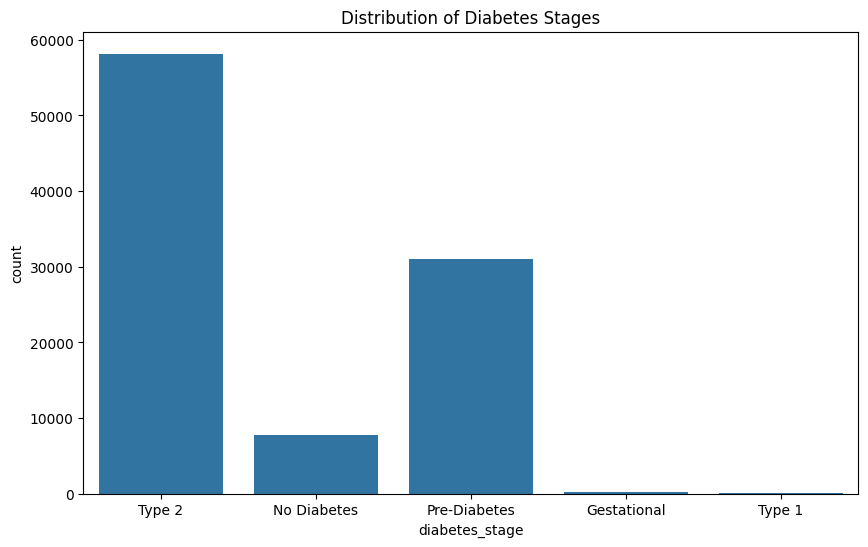

In [13]:
df['diabetes_stage'].value_counts()

sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stages")
plt.show()
# First counts how many records fall into each diabetes stage, then visualizes the distribution of diabetes stages


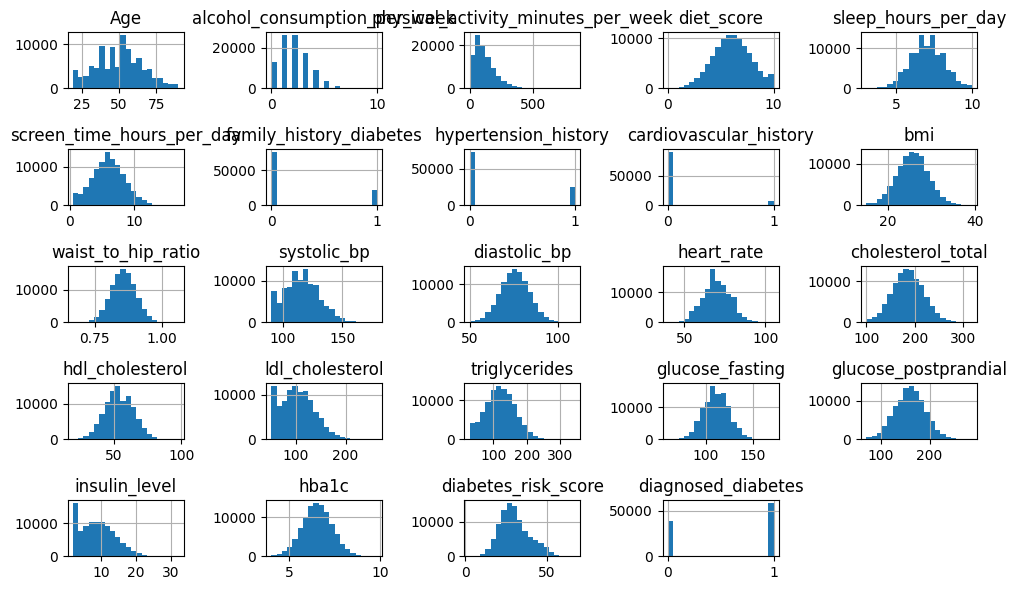

In [14]:
df.hist(bins=20)
plt.tight_layout()
plt.show()
# Plot histograms for all numerical features to understand distributions

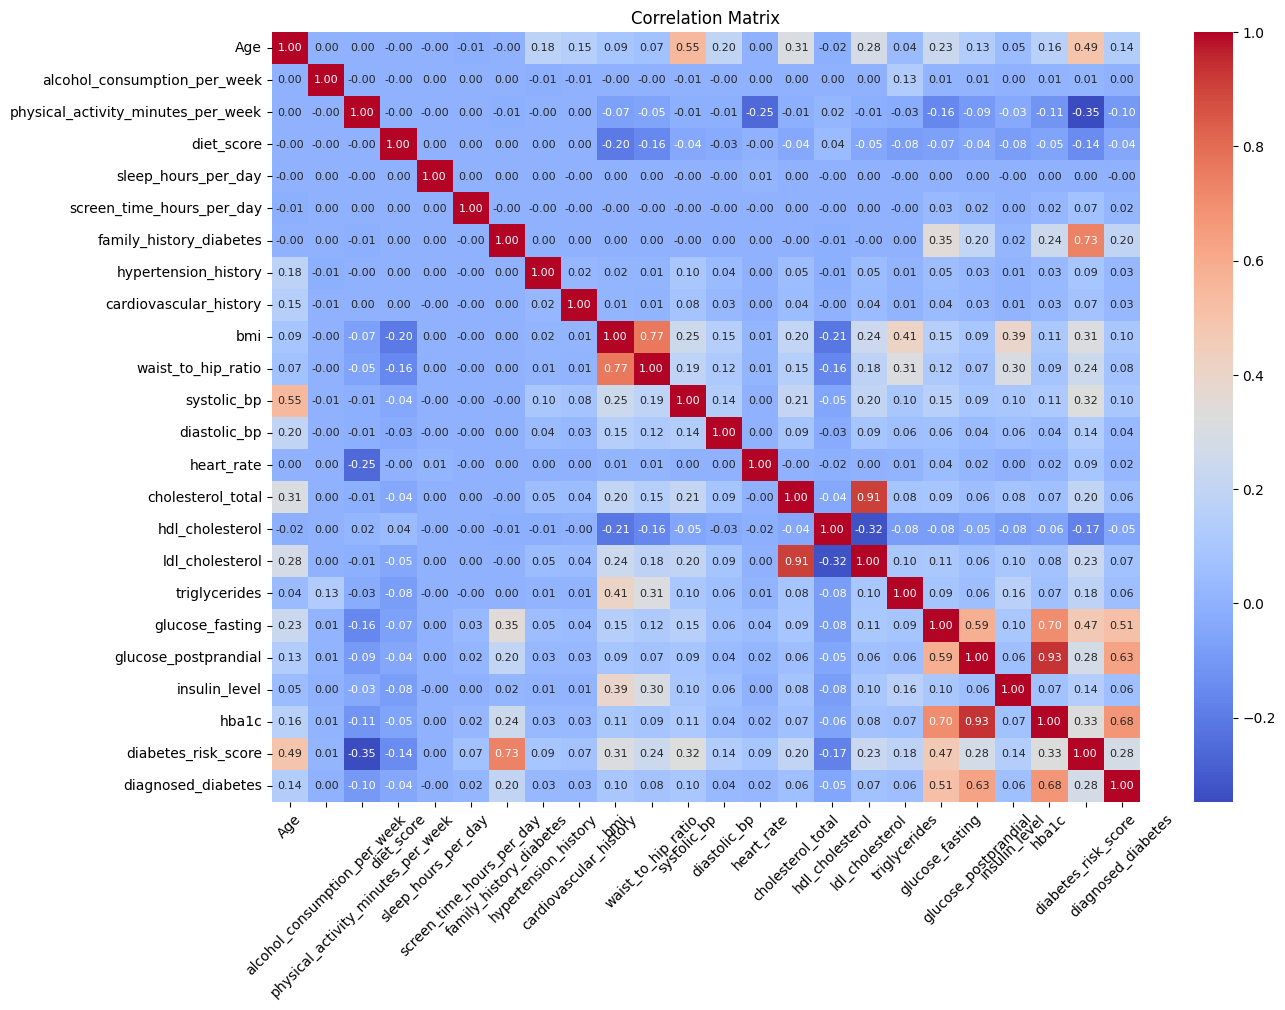

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))  # BIGGER FIGURE
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":8})
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()
# First computes the correlation matrix for numerical variables, then visualizes correlations using a heatmap


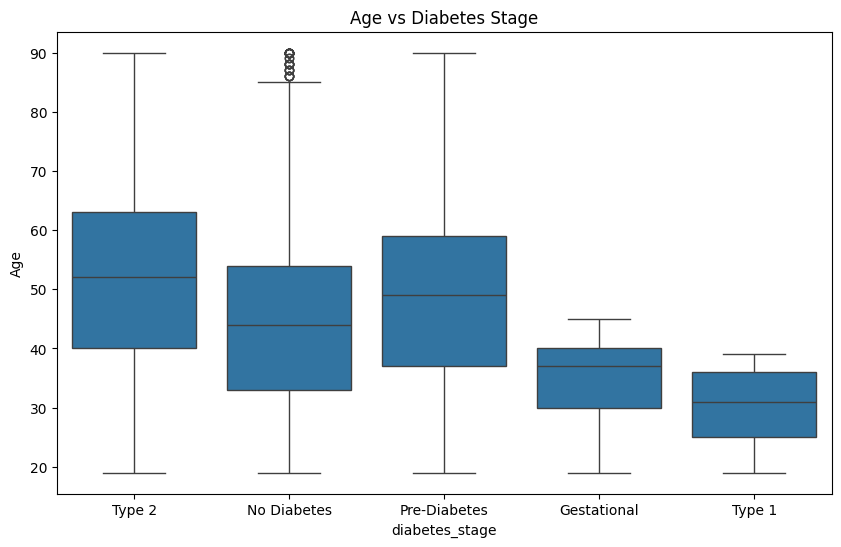

In [16]:
sns.boxplot(x='diabetes_stage', y='Age', data=df)
plt.title("Age vs Diabetes Stage")
plt.show()
# Compare Age distribution across diabetes stages

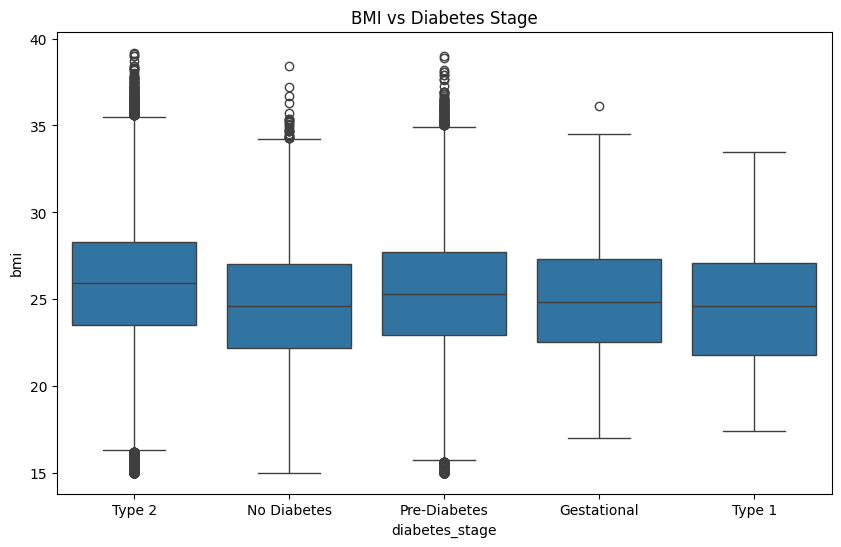

In [17]:
sns.boxplot(x='diabetes_stage', y='bmi', data=df)
plt.title("BMI vs Diabetes Stage")
plt.show()
# Compare BMI distribution across diabetes stages

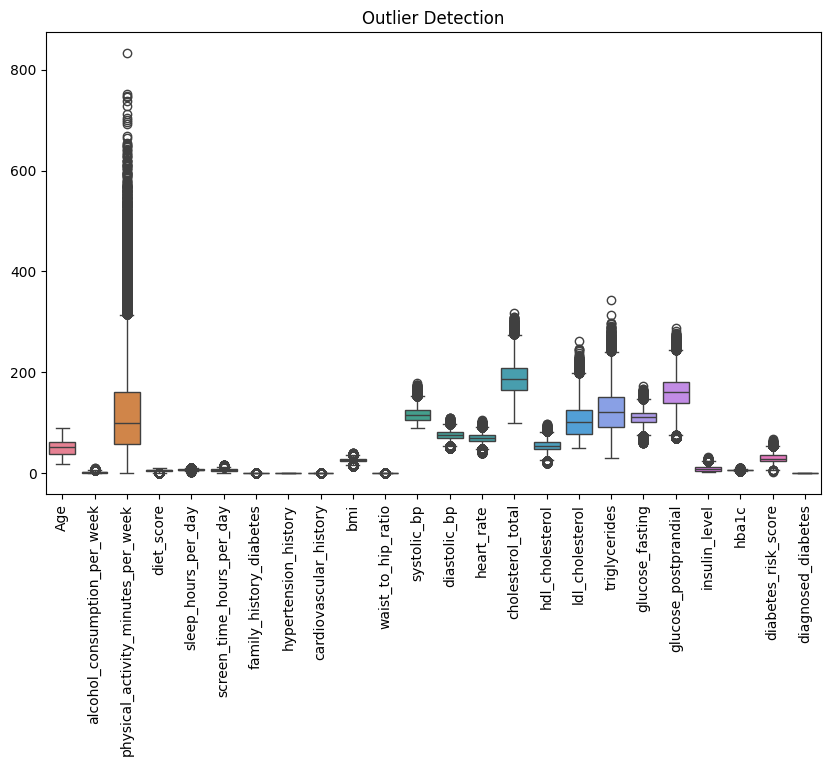

In [18]:
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()
# Detect outliers in numerical features using boxplots

In [19]:
# KEY INSIGHTS
# ============================================
# - The dataset contains multiple health and lifestyle features
# - The target variable (diabetes_stage) shows how patients are distributed across risk levels
# - Certain features, such as BMI and age, appear to vary across different diabetes stages
# - Outliers are present in some numerical variables
# - These findings will guide data preparation and modeling in the next phase



In [ ]:
# ============================================
# DATA Preprocessing PHASE
# ============================================
# Objective:
# Data Cleaning 
# Encoding 
# Handle outliers

In [12]:
#check for duplicate values
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes]
Index: []

[0 rows x 31 columns]


In [20]:
#Data Reduction - removing unecessary columns for modeling(Feature Selection) for predicting diabetes stage 

X = df.drop("diabetes_stage", axis=1)
y = df["diabetes_stage"]

#Convert catergorial values 
X = pd.get_dummies(X)

model = RandomForestClassifier()
model.fit(X,y)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                               feature  importance
23                  diagnosed_diabetes    0.424851
21                               hba1c    0.262056
18                     glucose_fasting    0.115664
19                glucose_postprandial    0.106147
22                 diabetes_risk_score    0.011770
6              family_history_diabetes    0.005245
0                                  Age    0.005169
2   physical_activity_minutes_per_week    0.005019
9                                  bmi    0.004515
17                       triglycerides    0.004095
11                         systolic_bp    0.004055
5            screen_time_hours_per_day    0.004037
20                       insulin_level    0.003995
3                           diet_score    0.003946
14                   cholesterol_total    0.003940
16                     ldl_cholesterol    0.003706
4                  sleep_hours_per_day    0.003686
15                     hdl_cholesterol    0.003685
12                        diast

In [21]:
#diagnosed_diabetes has a 0.424851 importance which makes it unrelaistic and there's a presence of data leakage.
# This makes the model look very accurate during training, but it’s misleading because it’s cheating
#it’s learning from data that won’t be available in real-world use. As a result, the model won’t perform as well on new, unseen data. 
#In simple terms, data leakage is like giving a student the answers while testing them ,they score high but haven’t truly learned anything useful.

In [28]:
#Remove data leakage 
X = df.drop([ "diabetes_stage", "diagnosed_diabetes"], axis=1)
y = df["diabetes_stage"]

X = pd.get_dummies(X)
model = RandomForestClassifier()
model.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


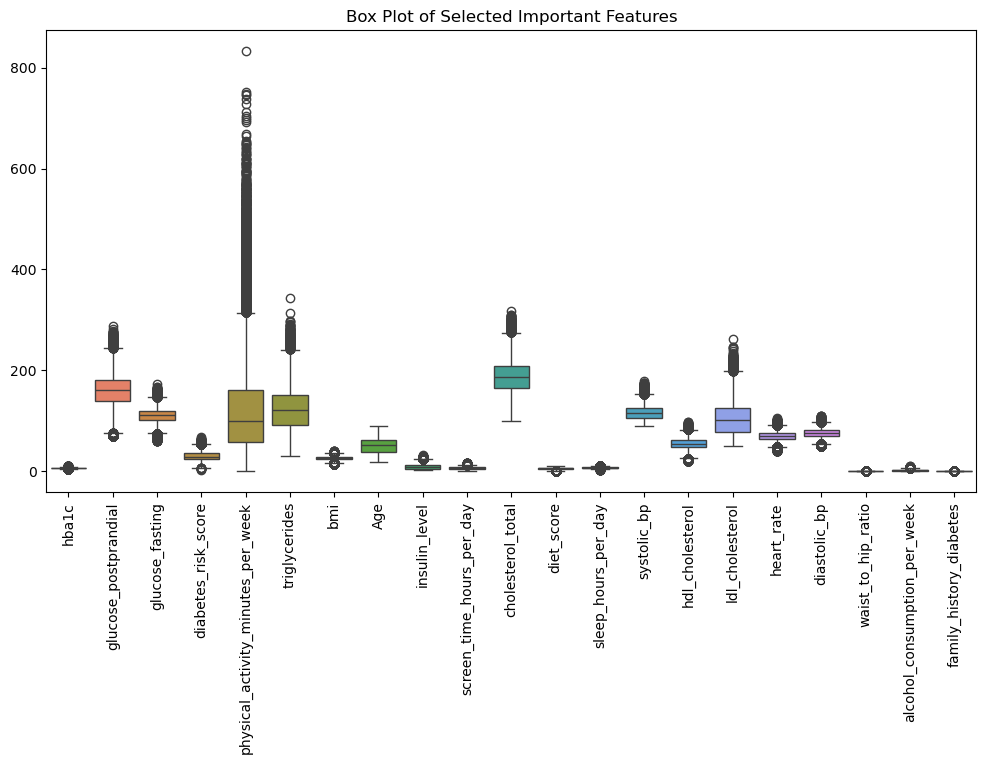

In [53]:
#which feature matter for prediction ?
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

important_features = feature_importance_df[
    feature_importance_df["importance"] > 0.005
]

selected_columns = important_features["feature"]
X_selected = X[selected_columns]

#plot boxplot to identify outliers 

plt.figure(figsize=(12,6))
sns.boxplot(data=X_selected)
plt.xticks(rotation=90)
plt.title("Box Plot of Selected Important Features")
plt.show()

In [54]:
X[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
hba1c,97297.0,6.520338,0.813710,4.00,5.97,6.52,7.07,9.80
glucose_postprandial,97297.0,160.014348,30.938915,70.00,139.00,160.00,181.00,287.00
glucose_fasting,97297.0,111.121792,13.590382,60.00,102.00,111.00,120.00,172.00
diabetes_risk_score,97297.0,30.222027,9.065063,2.70,23.80,29.00,35.60,67.20
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
triglycerides,97297.0,121.466407,43.393422,30.00,91.00,121.00,151.00,344.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
insulin_level,97297.0,9.063591,4.956342,2.00,5.09,8.79,12.45,32.22
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80


In [55]:
# compute skewness automatically
skewness = X_selected.skew().sort_values(ascending=False)

print(skewness)

physical_activity_minutes_per_week    1.390451
family_history_diabetes               1.354286
alcohol_consumption_per_week          0.702080
diabetes_risk_score                   0.513594
insulin_level                         0.423257
ldl_cholesterol                       0.319729
systolic_bp                           0.219172
Age                                   0.129394
triglycerides                         0.104238
screen_time_hours_per_day             0.083622
glucose_fasting                       0.045812
cholesterol_total                     0.032767
hba1c                                 0.030311
glucose_postprandial                  0.025540
diastolic_bp                          0.007730
bmi                                   0.005636
waist_to_hip_ratio                    0.003370
hdl_cholesterol                      -0.003319
sleep_hours_per_day                  -0.010653
heart_rate                           -0.018223
diet_score                           -0.071064
dtype: float6

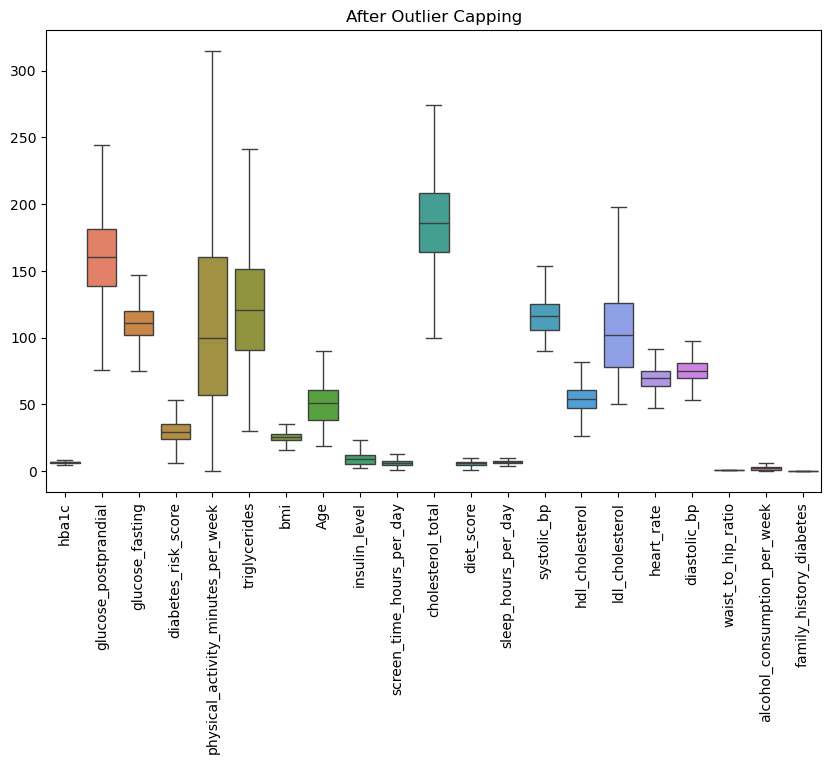

In [57]:
#Capping Technique

Q1 = X_selected.quantile(0.25)
Q3 = X_selected.quantile(0.75)
IQR = Q3 - Q1

X_capped = X_selected.copy()

for col in X_selected.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]

    X_capped[col] = X_selected[col].clip(lower, upper)
    
sns.boxplot(data=X_capped)
plt.xticks(rotation=90)
plt.title("After Outlier Capping")
plt.show()

In [60]:


#Boxplot defines outliers as values outside IQR bounds
#After capping:
#all values are inside bounds
#so boxplot shows no outliers
#This shows that the dataset is fairly clean most skewness was from categorical variables,numeric features were well-behaved/controlled

#How many values were modified per column
(X_selected != X_capped).sum()


hba1c                                   599
glucose_postprandial                    617
glucose_fasting                         722
diabetes_risk_score                     889
physical_activity_minutes_per_week     3115
triglycerides                           291
bmi                                     729
Age                                       0
insulin_level                           322
screen_time_hours_per_day               302
cholesterol_total                       296
diet_score                              325
sleep_hours_per_day                     870
systolic_bp                             517
hdl_cholesterol                         555
ldl_cholesterol                         340
heart_rate                              836
diastolic_bp                            717
waist_to_hip_ratio                      265
alcohol_consumption_per_week            443
family_history_diabetes               21372
dtype: int64

In [61]:
X_selected.corr()

,hba1c,glucose_postprandial,glucose_fasting,diabetes_risk_score,physical_activity_minutes_per_week,triglycerides,bmi,Age,insulin_level,screen_time_hours_per_day,...,diet_score,sleep_hours_per_day,systolic_bp,hdl_cholesterol,ldl_cholesterol,heart_rate,diastolic_bp,waist_to_hip_ratio,alcohol_consumption_per_week,family_history_diabetes
hba1c,1.000000,0.933174,0.700328,0.330464,-0.112289,0.066224,0.110229,0.159293,0.072736,0.024040,...,-0.054412,0.001577,0.110884,-0.059348,0.075256,0.024486,0.044595,0.087803,0.006455,0.242931
glucose_postprandial,0.933174,1.000000,0.589210,0.277470,-0.093567,0.057278,0.092516,0.132566,0.060987,0.020621,...,-0.044979,0.000856,0.093678,-0.049861,0.064291,0.018603,0.036734,0.073922,0.005257,0.204973
glucose_fasting,0.700328,0.589210,1.000000,0.470278,-0.161445,0.087473,0.151253,0.231403,0.102840,0.033387,...,-0.072204,0.001556,0.154084,-0.081652,0.105112,0.043440,0.064219,0.117856,0.007457,0.345316
diabetes_risk_score,0.330464,0.277470,0.470278,1.000000,-0.347707,0.181422,0.314368,0.494831,0.142905,0.070170,...,-0.144465,0.003162,0.323446,-0.174426,0.228091,0.091734,0.135540,0.242037,0.010793,0.733182
physical_activity_minutes_per_week,-0.112289,-0.093567,-0.161445,-0.347707,1.000000,-0.026237,-0.071631,0.003020,-0.034125,0.001103,...,-0.002773,-0.004995,-0.008170,0.018163,-0.014330,-0.253699,-0.008613,-0.053595,-0.002082,-0.006775
triglycerides,0.066224,0.057278,0.087473,0.181422,-0.026237,1.000000,0.405606,0.040028,0.163816,-0.004595,...,-0.080170,-0.003513,0.104155,-0.084232,0.098719,0.009281,0.061700,0.311000,0.126534,0.003885
bmi,0.110229,0.092516,0.151253,0.314368,-0.071631,0.405606,1.000000,0.093728,0.392163,-0.003568,...,-0.201331,0.000546,0.246302,-0.211943,0.238953,0.014459,0.150671,0.766123,-0.002852,0.000439
Age,0.159293,0.132566,0.231403,0.494831,0.003020,0.040028,0.093728,1.000000,0.045420,-0.006167,...,-0.003175,-0.003505,0.547095,-0.015338,0.281130,0.000149,0.196525,0.070225,0.000774,-0.002675
insulin_level,0.072736,0.060987,0.102840,0.142905,-0.034125,0.163816,0.392163,0.045420,1.000000,0.002066,...,-0.080781,-0.000992,0.096819,-0.083107,0.096097,0.002173,0.060726,0.302888,0.001075,0.017002
screen_time_hours_per_day,0.024040,0.020621,0.033387,0.070170,0.001103,-0.004595,-0.003568,-0.006167,0.002066,1.000000,...,0.003059,0.004599,-0.002932,-0.001518,0.001345,-0.000146,-0.000349,-0.003939,0.001794,-0.002001


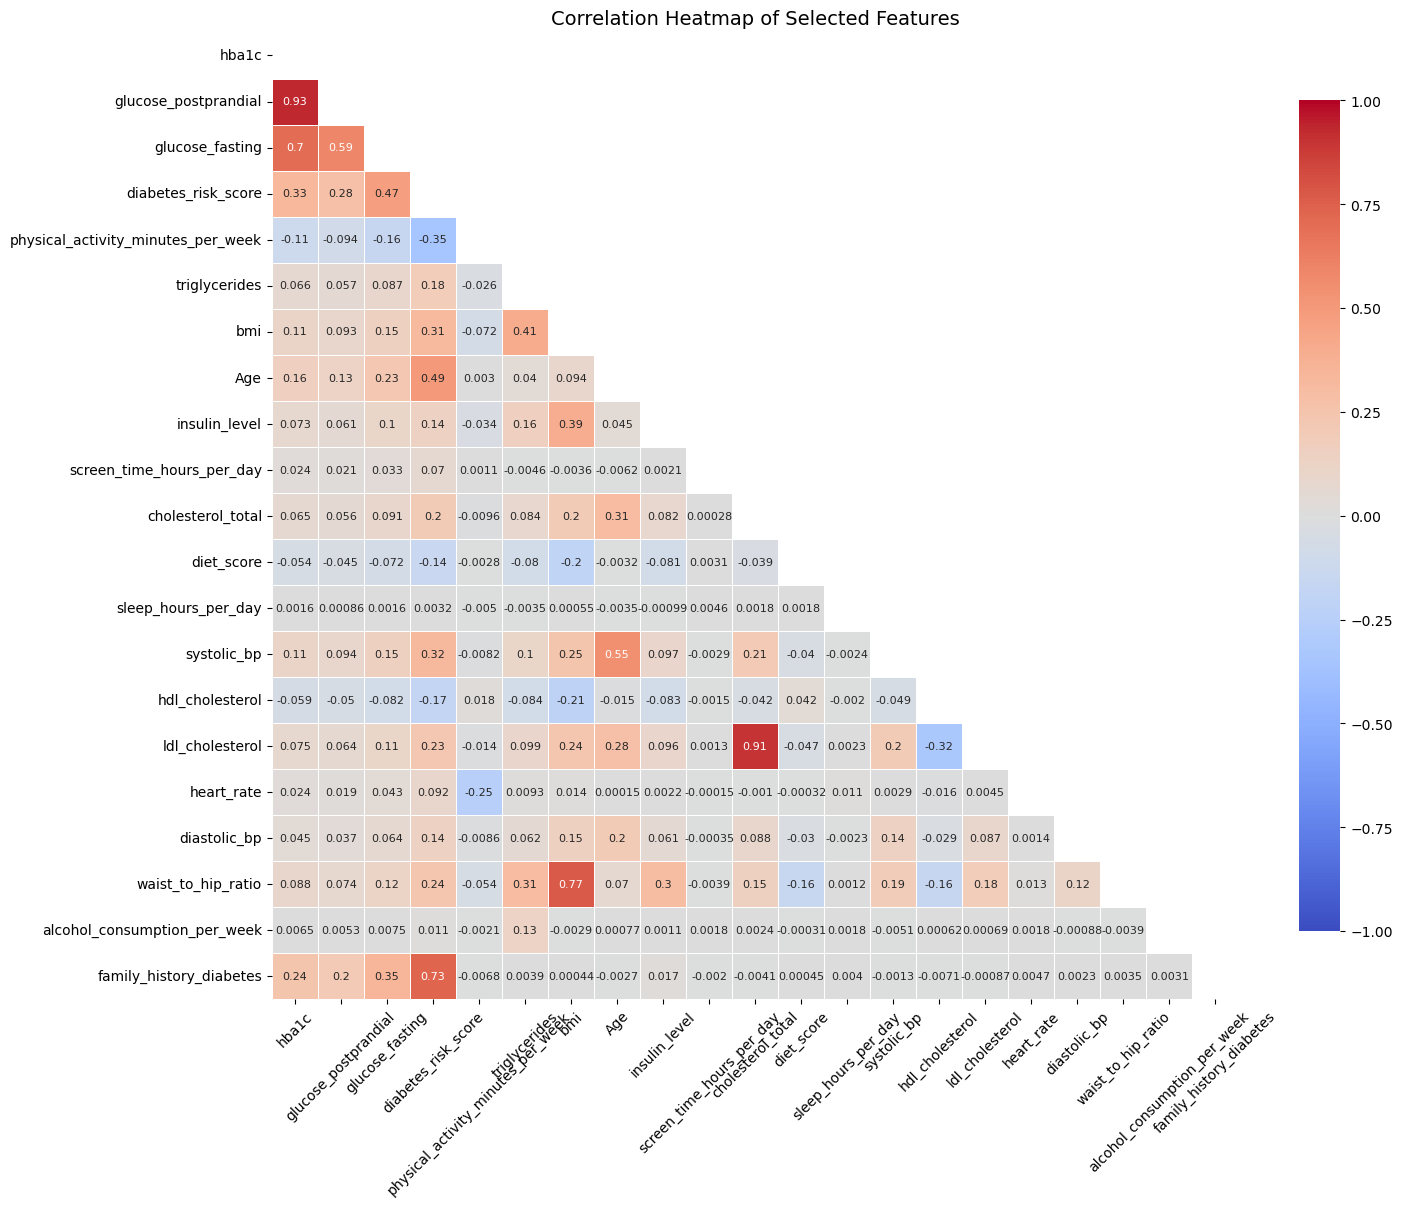

In [71]:
mask = np.triu(np.ones_like(X_selected.corr(), dtype=bool))

fig, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    X_selected.corr(),
    square=True,
    linewidths=0.5,
    cmap='coolwarm',
    cbar_kws={'shrink': 0.6},
    vmin=-1,
    vmax=1,
    annot=True,
    annot_kws={'size': 8},   # smaller text
    mask=mask,
    ax=ax
)

plt.title("Correlation Heatmap of Selected Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##################################################
# KEY-INSIGHTS
##################################################
#The data preparation process involved cleaning the dataset, encoding categorical variables into numerical form, and handling outliers using capping techniques. 
#After this process, no extreme outliers were observed, indicating that the data distribution had been effectively controlled. 
#As a result, the dataset is now well-structured and ready for the model selection phase.